# Lesson 3: Adding Forecasting to Priority Bank

Today we’re going to add something really cool to Priority Bank — a way to *guess* how long it will take to save up for your next goal. This is called **forecasting**, and it uses your past saving habits to make smart predictions about the future.
> 👯 **Work in pairs!** One person types (the **Driver**), the other guides (the **Navigator**). Switch roles after each exercise.

### Exercises
1. Identifying data patterns
2. Understand the linear regression algorithm
3. Implement linear regression for Priority Bank

## What is forecasting?
Nobody can see the future, but we can learn from our past! That’s what **forecasting** is all about.

In Priority Bank, every time you save money or move funds between goals, the app remembers it. By looking at your past transactions, we can spot patterns: maybe you save a little each week, or sometimes you get a bigger boost from babysitting. With this information, we can estimate how many days it might take you to reach your next goal, as long as:
1) You continue to act like you always have
2) All savings you make go towards this goal

Think of it like a “time-to-goal” crystal ball — it won’t be perfect, but it will give you a smart guess based on your own habits.

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('style.mplstyle')

In [2]:
from google.colab import files
uploaded = files.upload()

ModuleNotFoundError: No module named 'google.colab'

In [40]:
data = pd.read_csv("transactions.csv")
data = data.query("type == 'deposit'").copy()
data["date"] = pd.to_datetime(data.date, format="mixed")
data = data.set_index('date')
data = data.sort_index()
data

,goal_id,type,amount,description
date,,,,
2025-09-04,1,deposit,15,Allowance
2025-09-07,1,deposit,10,Weekly save
2025-09-10,1,deposit,18,Chores
2025-09-11,1,deposit,15,Allowance
2025-09-15,1,deposit,22,Babysitting
2025-09-18,1,deposit,8,Snack savings
2025-09-25,1,deposit,15,Allowance
2025-09-28,1,deposit,10,Weekly save
2025-10-02,1,deposit,18,Chores


---
## Exercise 1: Explore data patterns

In the data we have a list of **deposits**.

A deposit means **money being added to your account**.  
For example when you:

- get pocket money
- earn money from chores
- get birthday money

### Your task

Run the code (with the Play button) and look at the plots and the data. Think about:

- When does money get added?
- Is the savings growing slowly or quickly?
- Do you notice any patterns?

You are now **data detectives** 🕵️‍♀️.

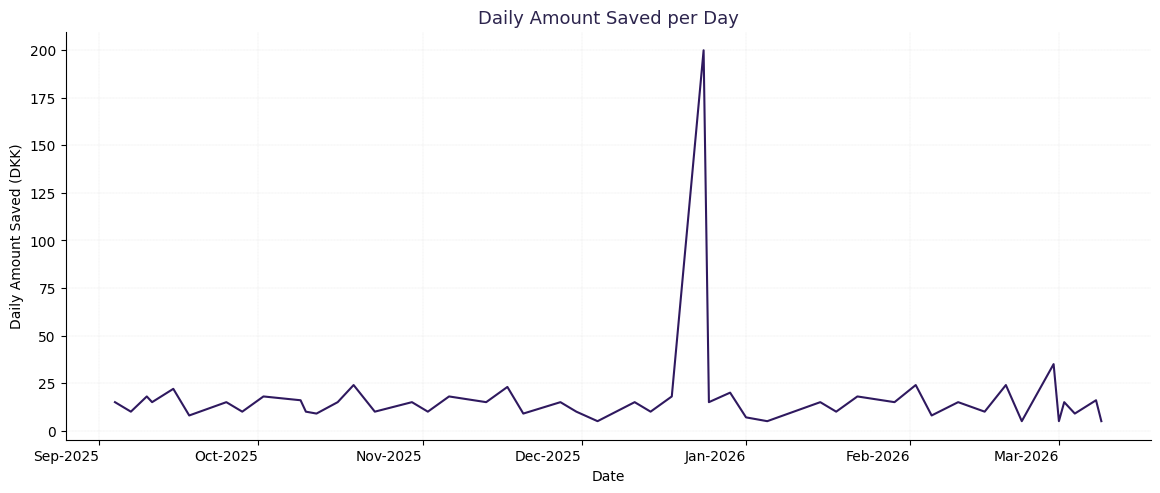

In [54]:
plt.figure(figsize=(14,6))
data.groupby('date').amount.sum().plot()

plt.xticks(rotation=0)
plt.title("Daily Amount Saved per Day")
plt.xlabel('Date')
plt.ylabel('Daily Amount Saved (DKK)')
plt.show()

Now we want to look at our accumulated savings over time. Run the code below to see the graph.

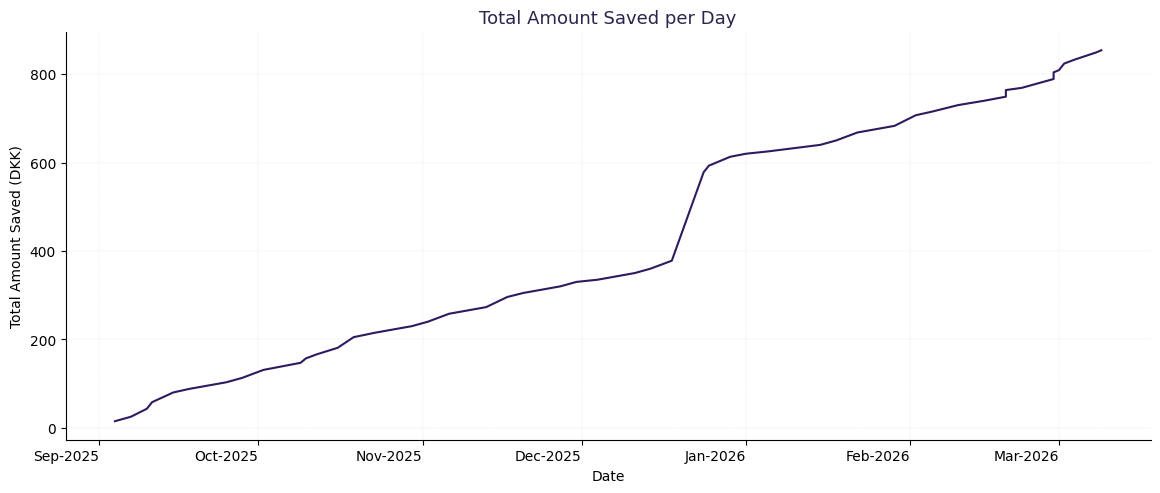

In [47]:
plt.figure(figsize=(14,6))
data['amount'].cumsum().plot()

plt.xticks(rotation=0)
plt.title("Total Amount Saved per Day")
plt.xlabel('Date')
plt.ylabel('Total Amount Saved (DKK)')
plt.show()

### What activities earn you money? 💰

In your bank app you might earn money in different ways, for example:

- doing chores 🧹  
- helping someone 🧑‍🤝‍🧑  
- getting pocket money 🪙  
- birthday gifts 🎂  

The graph below shows **how much money was earned from different activities over time**.

Each dot is **one deposit** (money added to the account).

### Your task

Look at the graph and think about:

- Which activity earns the **most money**?
- Which activity happens **most often**?
- Do some activities only happen on certain days?

You are looking for **patterns in the data**.

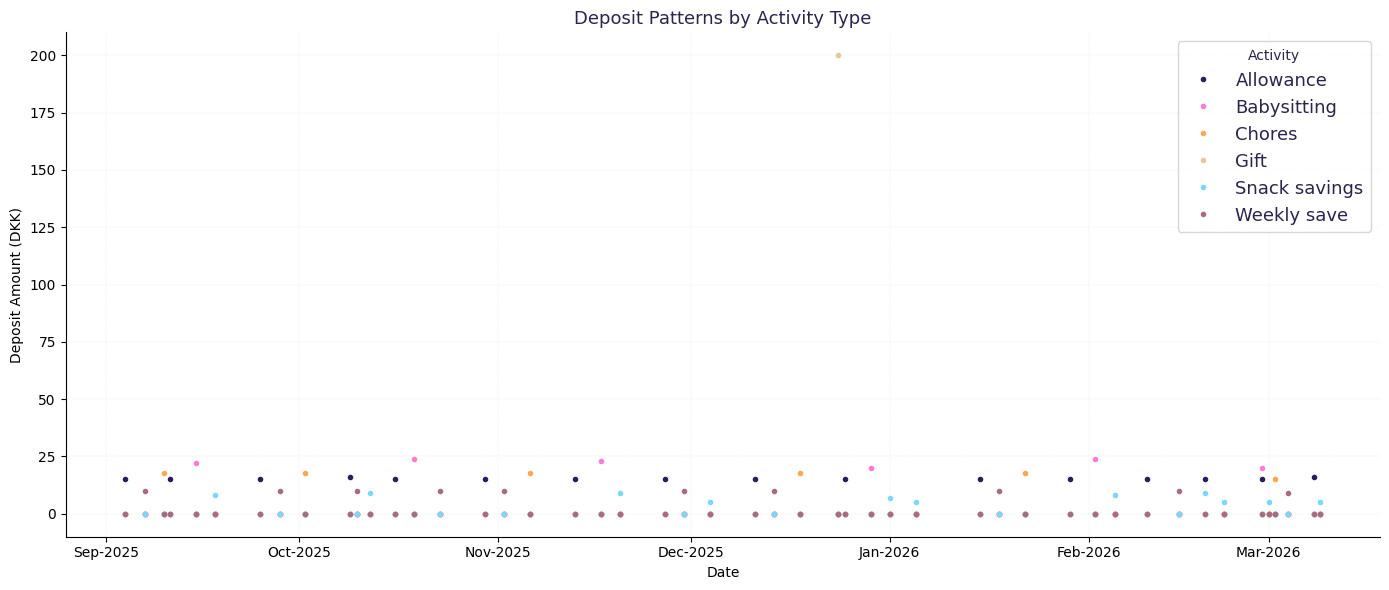

In [55]:
grouped = data.groupby(['date', 'description'])['amount'].sum().unstack(fill_value=0)

plt.figure(figsize=(14,6))
for note in grouped.columns:
    plt.plot(grouped.index, grouped[note], marker='.', linestyle="", label=note)

plt.title("Deposit Patterns by Activity Type")
plt.xlabel("Date")
plt.ylabel("Deposit Amount (DKK)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Activity")
plt.tight_layout()
plt.show()

As before, now we want to look at the accumulated savings over time for each of the categories. Run the code below to see the graph!

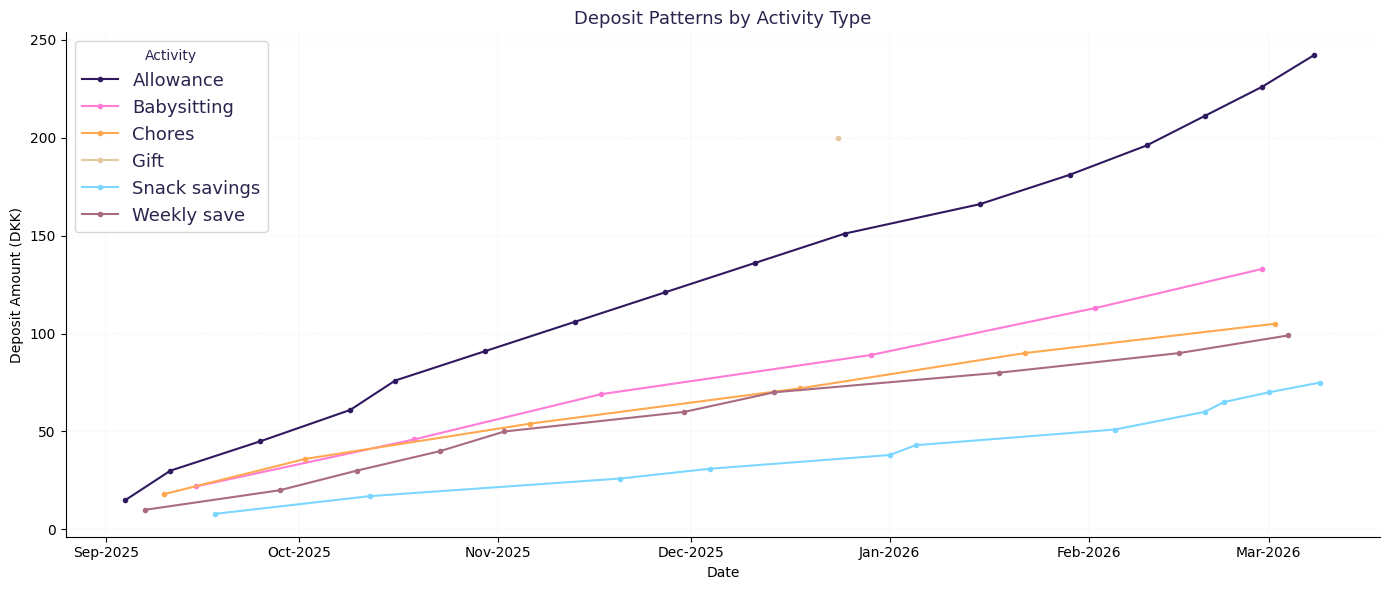

In [56]:
grouped = data.groupby(['date', 'description'])['amount'].sum().unstack()

plt.figure(figsize=(14,6))
for note in grouped.columns:
    temp = grouped[note].cumsum()
    temp = temp[temp.notna()]
    plt.plot(temp.index, temp, marker= ".",label=note)

plt.title("Deposit Patterns by Activity Type")
plt.xlabel("Date")
plt.ylabel("Deposit Amount (DKK)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Activity")
plt.tight_layout()
plt.show()

---
## Linear regression

Imagine you save **20 kr every day**.

Day 1 → 20 kr  
Day 2 → 40 kr  
Day 3 → 60 kr  
Day 4 → 80 kr  

If this keeps going, how much will you have on **Day 5**?

You probably noticed a **pattern**.

Linear regression is a way for a computer to **find the pattern in the data** and draw the **best straight line** through the points.

That line helps us **predict what might happen next**.

### How it works: The math
1. Imagine you’ve saved money over several days. Each day (`day`) you save an additional amount of money that is added to the total savings (`savings`). We write:
$$
\text{Total \texttt{savings}}=\texttt{savings}_{\texttt{day}_1} + \texttt{savings}_{\texttt{day}_2} + \texttt{savings}_{\texttt{day}_3} + ... + \texttt{savings}_{\texttt{day}_n} 
$$
2. However, in linear regression we are trying to find the averages of these historical savings to re-write this statement as:
$$
\text{Total \texttt{savings}}=m⋅\text{Number of \texttt{day}s}+b
$$
This means that in order to talk about future savings, we don't need to know the specific amount we are going to save on each future day, but can instead use the ideas of how much we on average save pr. day ($m$) and what we historically already know we have saved ($b$). More on how we find $m$ and $b$ below.
3. Once we have $m$ and $b$, we can predict the day you’ll reach your goal by solving the above equation for the number of days:
$$
\text{Number of \texttt{day}s}=\frac{\text{Total \texttt{savings}}−b​}{m}
$$

### How to find $m$: The rate of change
In linear regression, we often call $m$ the slope or rate of change of our data. In this example, $m$ is equal to the average amount of money we save per day. We can calculate $m$ by looking at how each day’s savings compares to the average and seeing how that relates to the total savings:
1. We find the average day and average amount saved per day.
2. We compare each day and savings amount on that day to the averages
3. We multiply these comparisons to understand how days and amount saved per day move together
4. We add all days together to get the totals
5. We take into account over how long we have saved by dividing with this

Using math, these steps become the function:
$$
m = \frac{\sum_{i=1}^N{(\texttt{day}_i\widehat{\texttt{day}})(\texttt{savings}_i-\widehat{\texttt{savings}})}}{\sum_{i=1}^N{(\texttt{day}_i-\widehat{\texttt{day}})^2}}
$$

### How to find $b$: The intercept
The intercept $b$ can be found by rearranging the best fit line considering that we know exactly two points on it: $\widehat{\texttt{day}}$ and $\widehat{\texttt{savings}}$
$$
\widehat{\texttt{savings}}=m⋅\widehat{\texttt{day}}+b \Leftrightarrow b = \widehat{\texttt{savings}} - m * \widehat{\texttt{day}}
$$

## Exercise 2: Understand linear regression



Now it’s time to see linear regression in action!

In this activity, we have some savings over a few days. We save it in two **list** which you have learned about before. The computer will look at your numbers, find the best line that fits them, and even **guess how much you’ll save on the next day**.

Let’s watch how it works — and see if the computer can predict the future!

In [37]:
# Days and savings
days = [1,2,3,4]
savings = [10,20,30,40]

# Calculate average day and avarage savings
avg_days = sum(days) / len(days)
avg_savings = sum(savings) / len(savings)

# Calculate m and b
numerator = sum((days[i] - avg_days)*(savings[i] - avg_savings) for i in range(4))
denominator = sum((days[i]-avg_days)**2 for i in range(4))
m = numerator / denominator
b = avg_savings - m * avg_days

# Predict day 5
next_day = 5
prediction = m * next_day + b

print("Computer prediction for Day 5:", round(prediction), "kr")

Computer prediction for Day 5: 50 kr


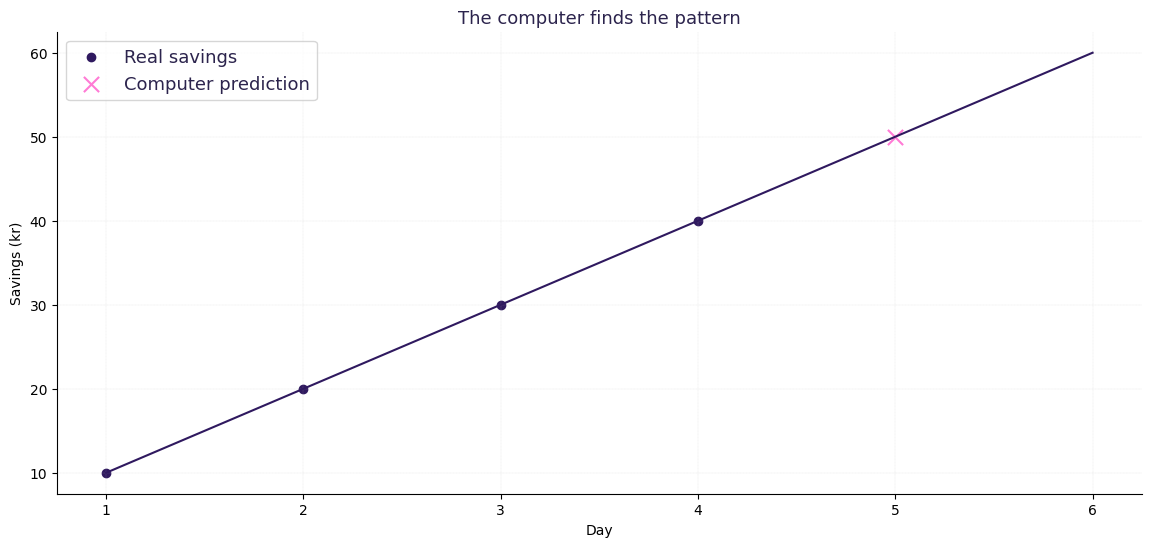

In [57]:
plt.scatter(days, savings, label="Real savings")

# predicted point
plt.scatter(next_day, prediction, marker="x", s=120, label="Computer prediction")

# draw regression line
x_line = np.linspace(1,6,100)
y_line = m*x_line + b
plt.plot(x_line, y_line)

plt.xlabel("Day")
plt.ylabel("Savings (kr)")
plt.title("The computer finds the pattern")
plt.legend()

plt.show()

# Computers Can Make Mistakes Too!

Uh-oh! Now we have some different numbers. This time the savings aren’t following a perfect line. The computer still tries to find the best line and **guess the next savings**, but it might **not be very close** to the real number.

Sometimes, you might even **guess better than the computer**! Let’s see who can predict Day 5 more accurately. What was your prediction for day 5?

In [58]:
# Days and savings
days = np.array([1,2,3,4])
savings = np.array([10,20,40,80])

# Calculate average day and avarage savings
avg_days = sum(days) / len(days)
avg_savings = sum(savings) / len(savings)

# Calculate m and b
numerator = sum((days[i] - avg_days)*(savings[i] - avg_savings) for i in range(4))
denominator = sum((days[i]-avg_days)**2 for i in range(4))
m = numerator / denominator
b = avg_savings - m * avg_days

# Predict day 5
next_day = 5
prediction = m * next_day + b

print("Computer prediction for Day 5:", round(prediction), "kr")

Computer prediction for Day 5: 95 kr


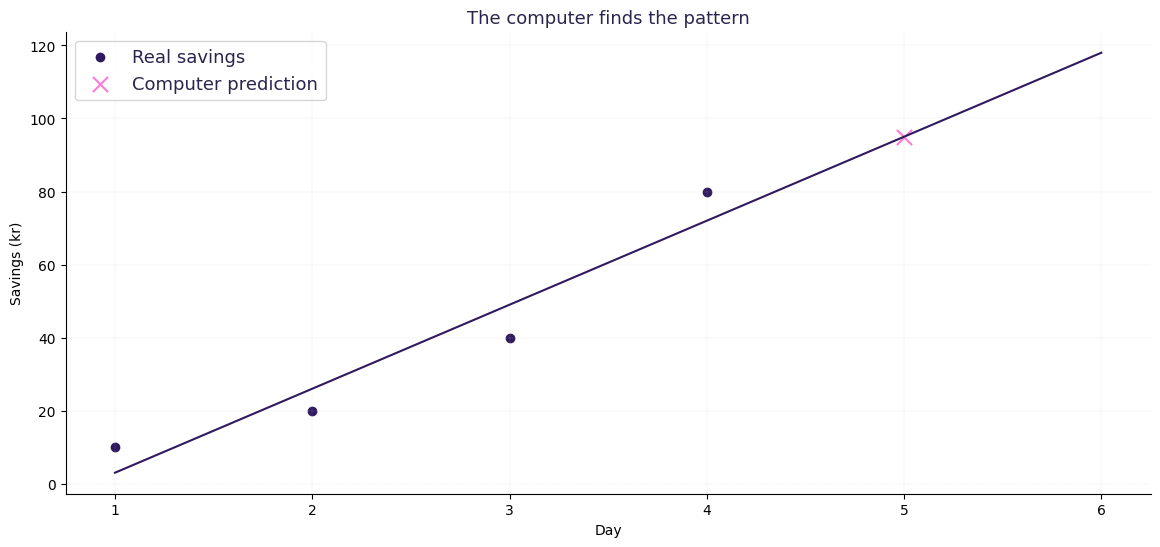

In [59]:
plt.scatter(days, savings, label="Real savings")

# predicted point
plt.scatter(next_day, prediction, marker="x", s=120, label="Computer prediction")

# draw regression line
x_line = np.linspace(1,6,100)
y_line = m*x_line + b
plt.plot(x_line, y_line)

plt.xlabel("Day")
plt.ylabel("Savings (kr)")
plt.title("The computer finds the pattern")
plt.legend()

plt.show()

---
## Exercise 3: 🚀 Extra Challenge: How Many Days Until Your Goal?

If you want to, you can try **writing a program to figure out how many days it will take to reach a savings goal**! We are here to help!

You’ll use the same line you learned about, but this time **solve for the day instead of the savings** 🌟

Here are some hints to get you started:  

- 📝 `find_m()` → calculate the slope **(how much savings grows each day)**  
- 📝 `find_b()` → calculate the y-intercept **(how much you start with on day 0)**  
- 🔢 To find the day for your goal: use the formula **day = (goal_amount - b) / m**  

In [11]:
def find_m(
    days: list[float],
    savings: list[float],
    avg_day: float ,
    avg_savings: float
):
    # TODO: Calculate the slope of the linear regression problem
    
    return b

In [12]:
def find_b(
    avg_day: float,
    avg_savings: float,
    m: float
):
    # TODO: Calculate the intercept of the linear regression problem

    return m

In [61]:
def find_m(
        days: list[float],
        savings: list[float],
        avg_day: float ,
        avg_savings: float
    ):
    """Find the m in y=m*x + b (slope) based on historical transactions."""
    # Calculate the numerator Σ_i(x_i-avg_x)*(y_i-avg_y)
    numerator = sum((days[i] - avg_day) * (savings[i] - avg_savings)
                for i in range(len(days)))

    # Calculate the denominator Σ_i(x_i-avg_x)**2
    denominator = sum((days[i] - avg_day) ** 2
                    for i in range(len(days)))

    m = numerator / denominator
    return m

def find_b(
        avg_day: float,
        avg_savings: float,
        m: float
    ):
    """Find the b in y=m*x+b (intercept) based on historical transactions."""
    # Calculate the intercept based on the function b=avg_y-m*avg_x
    return avg_savings - m * avg_day

In [62]:
def predict_how_days_to_total(historical_data, target_amount):
    """Predict n days forward in time using the historical data."""
    # Convert dates to day numbers
    historical_data = historical_data.copy()
    historical_data["day"] = (historical_data.index - historical_data.index.min()).days

    # Convert deposits to "total amount saved since first deposit" (our y)
    historical_data["total_saved"] = historical_data["amount"].cumsum()

    # Store x and y as lists
    days = historical_data["day"].to_list()
    savings = historical_data["total_saved"].to_list()

    # Calculate the averages
    avg_day = sum(days) / len(days)
    avg_savings = sum(savings) / len(savings)

    # Use your functions
    m = find_m(days, savings, avg_day, avg_savings)
    b = find_b(avg_day, avg_savings, m)

    # predict how much we have save on the nth day
    predicted_days = (target_amount - b)/m

    return predicted_days

Let's use your functions to calculate `b` and `m` and how long it would take use to save up 100 DKK

In [64]:
predicted_days1 = predict_how_days_to_total(data, 100)
print(f"If we base the prediction on all historical deposits, it takes ~{predicted_days1:.0f} days to save up 100 DKK")

# Run the prediction with all data expect the gift deposit
data_without_gift = data.query("description != 'Gift'").copy()

predicted_days2 = predict_how_days_to_total(data_without_gift, 100)
print(f"If we base the prediction on historical deposits excl. gift, it takes ~{predicted_days2:.0f} days to save up 100 DKK")

If we base the prediction on all historical deposits, it takes ~23 days to save up 100 DKK
If we base the prediction on historical deposits excl. gift, it takes ~18 days to save up 100 DKK
